<a href="https://colab.research.google.com/github/Anurag-snippet/ML_assignment/blob/main/TASK_2_problem_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#                                                                      TASK 1

In [7]:
#PROBLEM 1

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib
import random
import os

# seeds
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'

# versions
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)

# GPU check
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("\nGPU available:", gpus)
else:
    print("\nNo GPU detected")
    # CPU slower → less parallelism; GPU → faster via parallel computation

TensorFlow: 2.19.0
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0

No GPU detected


In [4]:
#PROBLEM 2

import tensorflow as tf
import numpy as np

# load datasets
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = tf.keras.datasets.mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = tf.keras.datasets.cifar10.load_data()

# (a) shapes
print("MNIST train:", mnist_x_train.shape, mnist_y_train.shape)
print("MNIST test:", mnist_x_test.shape, mnist_y_test.shape)

print("CIFAR-10 train:", cifar_x_train.shape, cifar_y_train.shape)
print("CIFAR-10 test:", cifar_x_test.shape, cifar_y_test.shape)

# (b) dtype and range
print("\nMNIST dtype:", mnist_x_train.dtype, "range:", mnist_x_train.min(), "-", mnist_x_train.max())
print("CIFAR dtype:", cifar_x_train.dtype, "range:", cifar_x_train.min(), "-", cifar_x_train.max())

# (c) class counts MNIST
counts = np.bincount(mnist_y_train)
print("\nMNIST class counts:", counts)

MNIST train: (60000, 28, 28) (60000,)
MNIST test: (10000, 28, 28) (10000,)
CIFAR-10 train: (50000, 32, 32, 3) (50000, 1)
CIFAR-10 test: (10000, 32, 32, 3) (10000, 1)

MNIST dtype: uint8 range: 0 - 255
CIFAR dtype: uint8 range: 0 - 255

MNIST class counts: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


/tmp/ipykernel_24215/3250977653.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(cifar_classes[int(cifar_y_train[idx])])


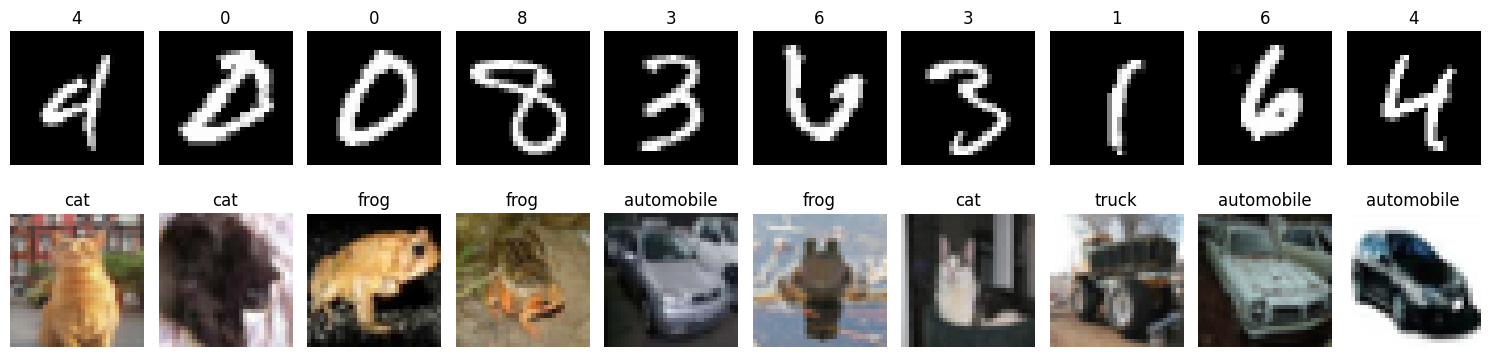

In [8]:
import matplotlib.pyplot as plt

# CIFAR class names
cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

plt.figure(figsize=(15,4))

# MNIST row
for i in range(10):
    idx = np.random.randint(0, len(mnist_x_train))
    plt.subplot(2,10,i+1)
    plt.imshow(mnist_x_train[idx], cmap='gray')
    plt.title(mnist_y_train[idx])
    plt.axis('off')

# CIFAR row
for i in range(10):
    idx = np.random.randint(0, len(cifar_x_train))
    plt.subplot(2,10,10+i+1)
    plt.imshow(cifar_x_train[idx])
    plt.title(cifar_classes[int(cifar_y_train[idx])])
    plt.axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

In [11]:
# PROBLEM 3

import tensorflow as tf
import numpy as np

# load MNIST
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

def preprocess(x, y):
    print("Before:")
    print("shape:", x.shape, "dtype:", x.dtype, "range:", x.min(), "-", x.max())
    print("label sample:", y[:5])

    # (a) normalize
    x = x.astype(np.float32) / 255.0
    print("\nAfter normalization:")
    print("dtype:", x.dtype, "range:", x.min(), "-", x.max())

    # (b) reshape
    if len(x.shape) == 3:
        x = x.reshape(-1, 28, 28, 1)
    print("\nAfter reshape:")
    print("shape:", x.shape)

    # (c) one-hot
    y = tf.keras.utils.to_categorical(y, 10)
    print("\nAfter one-hot:")
    print("shape:", y.shape)
    print("label sample:", y[:5])

    return x, y

x_train, y_train = preprocess(x_train, y_train)

Before:
shape: (60000, 28, 28) dtype: uint8 range: 0 - 255
label sample: [5 0 4 1 9]

After normalization:
dtype: float32 range: 0.0 - 1.0

After reshape:
shape: (60000, 28, 28, 1)

After one-hot:
shape: (60000, 10)
label sample: [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


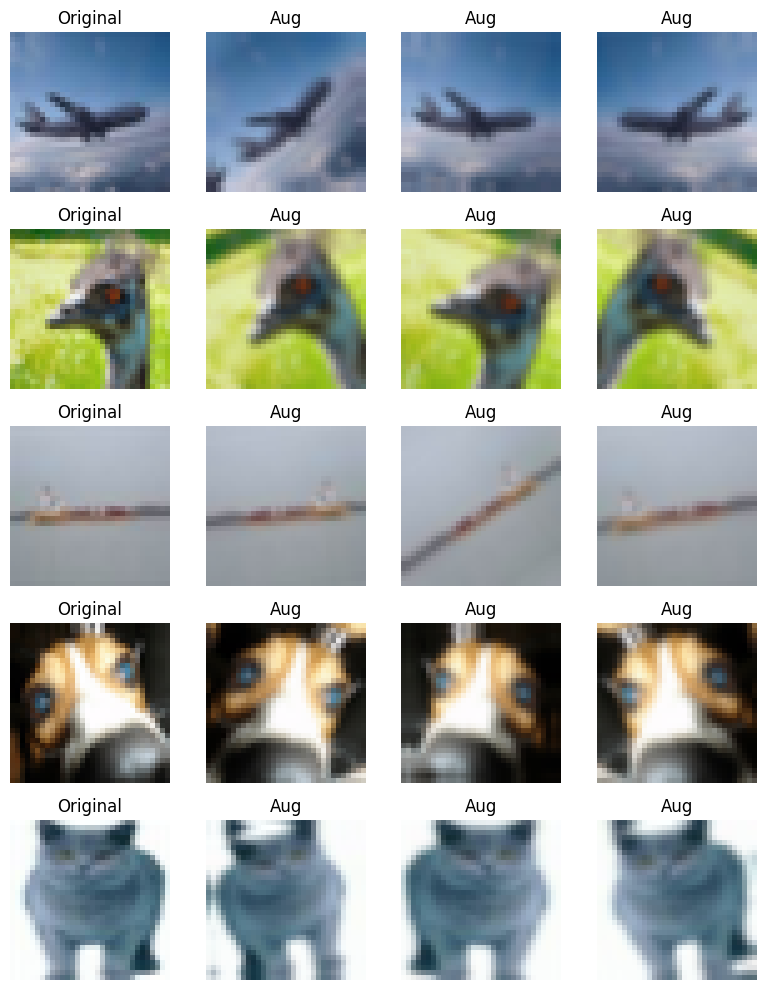

In [13]:
# PROBLEM 4

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

plt.figure(figsize=(8,10))

for i in range(5):
    idx = np.random.randint(0, len(x_train))
    img = x_train[idx]

    plt.subplot(5,4,i*4+1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    for j in range(3):
        aug_img = data_aug(tf.expand_dims(img, 0))[0].numpy().astype("uint8")
        plt.subplot(5,4,i*4+2+j)
        plt.imshow(aug_img)
        plt.title("Aug")
        plt.axis('off')

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

In [15]:
# ANALYSIS & REFLECTION QUESTIONS

# Q1. What does the channel dimension represent in a tensor of shape (N, H, W, C)? Explain with reference to
# both a greyscale image and an RGB image.
# Answer:
# In a tensor of shape (N, H, W, C), the channel dimension (C) represents the number of feature channels per image.
# For a greyscale image, C = 1 because each pixel has a single intensity value.
# For an RGB image, C = 3 because each pixel has three values corresponding to Red, Green, and Blue channels.

# Q2. CIFAR-10 images are 32×32 pixels. If you were training a CNN on 1024×1024 satellite images, what
# data loading strategies would you use to avoid running out of memory? Name at least two techniques and
# explain how each one helps.
# Answer:
# Mini-batch loading (Data generators): Load data in small batches instead of the entire dataset into memory. This reduces memory usage significantly.
# Image resizing / patching: Resize large images or split them into smaller patches (e.g., 256×256). This lowers memory requirements while still allowing training.
# On-the-fly loading (lazy loading): Load images from disk during training instead of storing all in RAM.

# Q3. Suppose a student applies normalisation to the test set using the mean and standard deviation
# computed from the test set itself. What is wrong with this approach?
# Answer:
# This approach causes data leakage because the test set information is used during preprocessing. The model indirectly gains knowledge about the test distribution, leading to overly optimistic performance.

# Correct approach: use mean and standard deviation computed only from the training set and apply the same transformation to validation and test sets.

In [ ]:
#                                                  TASK 2

In [16]:
# PROBLEM 1

import numpy as np

def conv2d(image, kernel, stride=1, padding=0):
    H, W = image.shape
    K = kernel.shape[0]

    # padding
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    H_p, W_p = image.shape

    out_h = (H_p - K) // stride + 1
    out_w = (W_p - K) // stride + 1

    output = np.zeros((out_h, out_w))

    for i in range(0, out_h):
        for j in range(0, out_w):
            region = image[i*stride:i*stride+K, j*stride:j*stride+K]
            output[i, j] = np.sum(region * kernel)

    return output


# test image
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

# Sobel-X kernel
kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

result = conv2d(image, kernel, stride=1, padding=0)

print("Output:\n", result)
print("Output shape:", result.shape)

Output:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output shape: (3, 3)
